# CSE2530 Computational Intelligence
## Assignment 2: Ant Colony Optimization and Genetic Algorithms

|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Dudała (6212743) |

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
import matplotlib.pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData

In [2]:
SEED = 42
random.seed(SEED)
np.SEED = 42
random.seed(SEED)

DIR_DELTA = {
    Direction.north: (0, -1),
    Direction.south: (0, 1),
    Direction.west: (-1, 0),
    Direction.east: (1, 0),
}

DIR_DELTA_LIST = list(DIR_DELTA.items())
DELTA_TO_DIR = {(1, 0): Direction.east, (-1, 0): Direction.west, (0, -1): Direction.north, (0, 1): Direction.south}

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1: Look into the literature and explain how the TSP problem is usually defined.

The **Travelling Salesman Problem** (TSP) is usually defined as the problem that, given a collection of cities and the distances of travel between each pair of them, we need to find the shortest way of visiting all of the cities and returning to the starting point.

C. Dahiya and S. Sangwan, "Literature review on travelling salesman problem," *International Journal of Research*, 2018.

#### Question 2: In a classic TSP, all cities (nodes) are singularly connected to all other nodes and relative distances are known and symmetric (aweighted complete graph). Give three ways in which our problem is different.

1. In our version, distances between nodes are not initially known and must first be calculated using the ACO algorithm.
2. We are working with a maze (a grid graph), not a complete graph, meaning nodes are not singularly connected but are connected through a sequence of accessible tiles. 
3. Given that ACO is a stochastic algorithm, it is likely that the found route from x to y might differ from one from y to x. 

#### Question 3: Why are computational intelligence techniques appropriate to solve the TSP? What are the characteristics which let us to tackle typically intractable problems?

TSP is an NP-hard problem with $n!$ number of possible solutions for $n$ cities. So far, the most optimal exact algorithms perform in $O(n^2 \cdot 2^n)$ time complexity which is extremely slow. Therefore, for larger applications, a heuristic algorithm is needed, and CI techniques provide such. 
The two most important characteristics allowing for tackling the problem are:
- **Exploitation** - we focus on the most promising results and discard those with poor results on the fitness function. This allows us to limit the search space from the initial $n!$ possibilities.
- **Exploration** - genetic mutation allows us to escape local optima in search of the best solution.

### 1.2 Genetic Algorithm

In [ ]:
# TSP problem solver using genetic algorithms
class GeneticAlgorithm:

    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    @param mutation_rate: the probability of mutation occurring in an offspring. Initialized to 0.01 by default. 
    @param crossover_rate: the probability of crossover occurring between parents. Initialized to 0.7 by default.
    @param elitism_size: the number of top-performing chromosomes preserved across generations. Initialized to 1 by default.
    """
    def __init__(self, generations, pop_size, mutation_rate=0.01, crossover_rate = 0.7, elitism_size=1):
        self.generations = generations
        self.pop_size = pop_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elitism_size = elitism_size

    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence and distance metrics.
    """
    def solve_tsp(self, tsp_data):
        population = self.initialize_population(len(tsp_data.product_locations))
        
        best_distances = []
        average_distances = []
        
        # Run generations
        for i in range(self.generations):
            distances = self.calculate_distances(population, tsp_data)
            fitness_scores = self.calculate_fitness(distances)
            
            best_distances.append(min(distances))
            average_distances.append(sum(distances) / len(distances))
            
            population = self.generate_new_population(population, fitness_scores)
            
        final_distances = self.calculate_distances(population, tsp_data)
        final_fitness_scores = self.calculate_fitness(final_distances)
        
        best_distances.append(min(final_distances))
        average_distances.append(sum(final_distances) / len(final_distances))
        
        best_chromosome = []
        highest_fitness = -1.0
        
        # Find the best chromosome
        for i in range(self.pop_size):
            if final_fitness_scores[i] > highest_fitness:
                highest_fitness = final_fitness_scores[i]
                best_chromosome = population[i]
                
        return best_chromosome, best_distances, average_distances

    """
    Initializes the population with random chromosomes.
    @param num_products: the number of products to visit.
    @return a list of generated chromosomes.
    """
    def initialize_population(self, num_products):
        population = []

        # Initialize population with random permutations
        for i in range(self.pop_size):
            population.append(random.sample(range(num_products), num_products)) # we append a random permutation of 0, ..., N-1 to population
        return population
    
    """
    Calculates the total distances for the given population.
    @param population: the current generation of chromosomes.
    @param tsp_data: the data describing the problem distances.
    @return a list of computed distance values corresponding to the population.
    """
    def calculate_distances(self, population, tsp_data):
        distances = []

        # Calculate distances for each chromosome
        for i in range(len(population)):
            chromosome = population[i]
            dist = tsp_data.start_distances[chromosome[0]]

            # Calculate distance for each pair of nodes
            for j in range(len(chromosome) - 1):
                dist += tsp_data.distances[chromosome[j]][chromosome[j+1]]
            
            dist += tsp_data.end_distances[chromosome[len(chromosome) - 1]]
            distances.append(dist)
            
        return distances

    """
    Calculates the fitness scores of the given population distances.
    @param distances: the computed distances for the population.
    @return a list of computed fitness values.
    """
    def calculate_fitness(self, distances):
        fitness_scores = []

        # Calculate fitness for each distance
        for dist in distances:
            fitness = 1 / max(float(dist), 1e-10)
            fitness_scores.append(fitness)
            
        return fitness_scores

    """
    Selects parent chromosomes for reproduction based on Roulette Wheel selection.
    @param population: the current generation of chromosomes.
    @param fitness_scores: the corresponding fitness values for the population.
    @return a tuple containing two selected parent chromosomes.
    """
    def select_parents(self, population, fitness_scores):
        parents = random.choices(population, weights=fitness_scores, k=2)
        return parents[0], parents[1]

    """
    Performs crossover between two parent chromosomes to create a child.
    @param parent1: the first parent chromosome.
    @param parent2: the second parent chromosome.
    @return the generated child chromosome.
    """
    def crossover(self, parent1, parent2):
        # since chromosome must be a valid permutation, we need to apply special Order Crossover
        # to create a child, we take a random substring from one parent and then fill remaining positions in relative order of genes from second parent 
        if random.random() >= self.crossover_rate:
            return parent1.copy()
            
        size = len(parent1)
        child = [-1] * size
        start = random.randint(0, size - 2)
        end = random.randint(start + 1, size - 1)
        
        # Fill child with genes from parent1
        for i in range(start, end + 1):
            child[i] = parent1[i]

        # Fill remaining positions with genes from parent2
        p2_idx = 0
        for i in range(size):

            # If position is not filled, fill with gene from parent2
            if child[i] == -1:
                while parent2[p2_idx] in child:
                    p2_idx += 1
                child[i] = parent2[p2_idx]
                
        return child

    """
    Applies random mutations to a chromosome.
    @param chromosome: the chromosome to mutate.
    @return the potentially mutated chromosome.
    """
    def mutate(self, chromosome):
        # since our chromosome is a random permutation, the most sensible mutation is to swap two values
        # We cannot just "flip" one entry, since this would lead to one node being unvisited and other visited twice
        if random.random() < self.mutation_rate:
            i1 = random.randint(0, len(chromosome) - 1)
            i2 = random.randint(0, len(chromosome) - 1)
            chromosome[i1], chromosome[i2] = chromosome[i2], chromosome[i1]
        return chromosome

    """
    Generates a new population of chromosomes through selection, crossover, and mutation.
    @param population: the current generation of chromosomes.
    @param fitness_scores: the corresponding fitness values for the population.
    @return a list containing the newly generated population.
    """
    def generate_new_population(self, population, fitness_scores):
        new_population = []
        indices = range(self.pop_size)
        sorted_indices = sorted(indices, key=lambda k: fitness_scores[k], reverse=True) # we sort indices by comparing fitness function per key and reverse to have best results first
        
        # Copy elitism_size best solutions to new population
        for i in range(self.elitism_size):
            elite_index = sorted_indices[i]
            new_population.append(population[elite_index])
            
        # Fill the rest of the population with new solutions
        while len(new_population) < self.pop_size:
            parent1, parent2 = self.select_parents(population, fitness_scores)
            child = self.crossover(parent1, parent2)
            mutated_child = self.mutate(child)
            new_population.append(mutated_child)
            
        return new_population

#### Question 4: What do the genes represent? How will you encode your chromosomes?

In our implementation, the $i$-th gene is a number from 0 to $N-1$ ($N$ being the number of nodes/products) that represents the $i$-th node that we will visit. We encode chromosomes as a permutation of $(0, 1, \dots, N-1)$, which tells us the order of visited nodes.

#### Question 5: Which fitness function will you use? Why is this a suitable choice?

We use $f(c) = \frac{1}{\text{dist}(c)}$ as our fitness function for chromosome $c$, with $\text{dist}(c)$ being the total length (distance) of the route encoded by chromosome $c$. We are interested in minimizing total distance, therefore the smaller the distance, the better the fitness score should be. We believe the simple inverse to be the most reasonable choice to ensure this.

#### Question 6: How are parents selected from the population?

Parents are selected using a **Roulette Wheel** selection, meaning that the chance of a chromosome being selected to be a parent is proportional to its fitness function. This ensures that the best solutions are chosen with a larger probability. Note that `random.choices` with fitness scores as weights is equivalent to picking a random number from $0$ to $1$ and slicing used in slides.

#### Question 7: What genetic operations did you implement? What are their functions (goals)?

We implement **mutation** and **cross-over**. The underlying assumption (exploration) of mutation is that unexpected changes in solutions can yield better solutions. The goal of cross-over is exploitation, the assumption that combining good results might lead to an even better result.

#### Question 8: How do you prevent local minima?

Getting stuck in local minima is prevented by **mutation**. By sometimes randomly mutating solutions, we check if a small random change doesn't perhaps lead to a better solution. 

#### Question 9: What is elitism? Have you applied it? Why (not)?

**Elitism** is a technique to directly copy a fixed number of best-performing solutions from the current generation to the next generation. This technique ensures that the fitness of the best individual can only increase from generation to generation. For a larger size of the elitism pool, it ensures that the high-quality chromosomes do not get lost. We implement it, tempted by the possibility of speeding up convergence.

#### Question 10: Apply your algorithm to find the shortest route using the provided data. What is the length of your solution? Is it optimal?

Number of products: 18
Optimized GA Distance: 1325.00


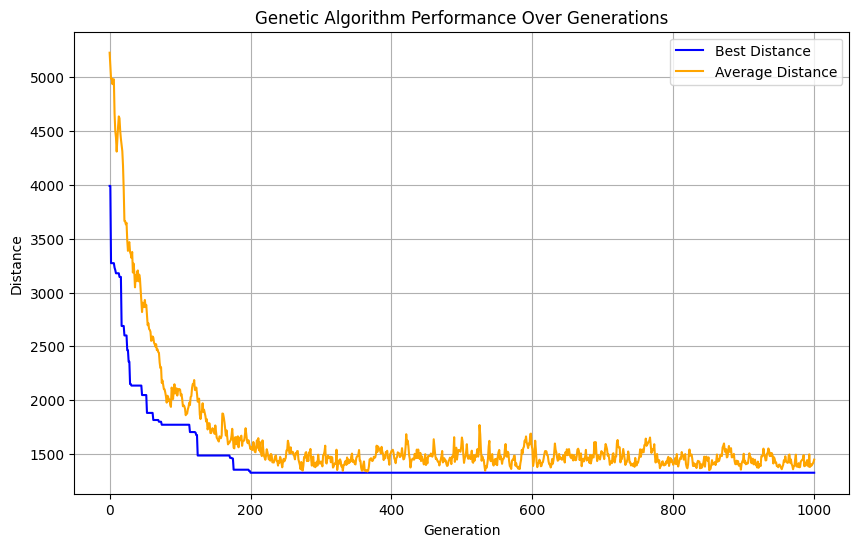

In [4]:
# I have noticed that despite setting up seed before, runs would give different results. So we fix seed immediately before running this part to fix the problem.
random.seed(42)
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 50
generations = 1000
mutation_rate = 0.05
crossover_rate = 0.8
elitism_size = 1
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size, mutation_rate, crossover_rate, elitism_size)

# Run optimzation and write to file
solution, best_distances, average_distances = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")

solution_distance = ga.calculate_distances([solution], tsp_data)[0]
print(f"Number of products: {len(tsp_data.product_locations)}")
print(f"Optimized GA Distance: {solution_distance:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(range(generations + 1), best_distances, label='Best Distance', color='blue')
plt.plot(range(generations + 1), average_distances, label='Average Distance', color='orange')
plt.xlabel('Generation')
plt.ylabel('Distance')
plt.title('Genetic Algorithm Performance Over Generations')
plt.legend()
plt.grid(True)
plt.show()

The length of our solution is 1325. We can see on the chart that this solution is reached at step around 200 and does not get better. However, in runs without a fixed seed, many results converged much later, so we keep the number of generations high to ensure we don't stop prematurely.   
We notice that number of nodes is 18, small enough for running exact algorithm in feasible time ($18^2 \cdot 2^{18} = 84,934,656$). Rather than admitting we can't be sure if we found an optimal solution since GA is heuristic, below we run a (AI-generated, we hope it's ok as this is not really part of the material) **Held-Karp algorithm** to compare results.

In [5]:
def solve_held_karp(tsp_data):
    num_products = len(tsp_data.product_locations)
    
    # Construct the full distance matrix
    # Index 0: Start, 1 to N: Products, N+1: End
    n = num_products + 2
    dist_matrix = np.zeros((n, n))
    
    # Fill distances from Start (0) to products (1 to num_products)
    for i in range(num_products):
        dist_matrix[0, i+1] = tsp_data.start_distances[i]
        dist_matrix[i+1, 0] = tsp_data.start_distances[i]
        
    # Fill distances between products
    for i in range(num_products):
        for j in range(num_products):
            dist_matrix[i+1, j+1] = tsp_data.distances[i][j]
            
    # Fill distances from products to End (n-1)
    for i in range(num_products):
        dist_matrix[i+1, n-1] = tsp_data.end_distances[i]
        dist_matrix[n-1, i+1] = tsp_data.end_distances[i]

    # DP state: (visited_mask, last_node)
    # We only permute the product nodes (1 to num_products)
    num_subsets = 1 << num_products
    memo = np.full((num_subsets, num_products), np.inf)

    # Initialize: distance from start to each product
    for i in range(num_products):
        memo[1 << i, i] = dist_matrix[0, i+1]

    # Iterate through subsets of increasing size
    for subset_size in range(2, num_products + 1):
        for subset in range(num_subsets):
            if bin(subset).count('1') != subset_size:
                continue
            
            for next_node in range(num_products):
                if not (subset & (1 << next_node)):
                    continue
                
                prev_subset = subset ^ (1 << next_node)
                for prev_node in range(num_products):
                    if not (prev_subset & (1 << prev_node)):
                        continue
                    
                    new_dist = memo[prev_subset, prev_node] + dist_matrix[prev_node+1, next_node+1]
                    if new_dist < memo[subset, next_node]:
                        memo[subset, next_node] = new_dist

    # Final step: add distance to the end point from the last product
    full_mask = num_subsets - 1
    optimal_distance = np.inf
    for i in range(num_products):
        total_dist = memo[full_mask, i] + dist_matrix[i+1, n-1]
        if total_dist < optimal_distance:
            optimal_distance = total_dist

    return optimal_distance


optimal_solution = solve_held_karp(tsp_data)

print(f"Held-Karp Distance: {optimal_solution:.2f}")

Held-Karp Distance: 1325.00


Interestingly, we see that GA has succeeded in finding an optimal solution. We also see that it has done so in a much shorter time (for us, 24 times shorter). Notice that if it takes 12 seconds to run roughly 90 mln "operations", running the solution for 30 nodes would already take longer than a day (as $30^2 \cdot 2^{30}$ is 7200 times larger).

## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11: What is the purpose of Ant Colony Optimisation? In what settings is it typically used?

The purpose of Ant Colony Optimisation is to find optimal or near-optimal solutions to complex optimisation problems by simulating how ants find the shortest path using pheromone trails. It is especially useful for discrete and combinatorial optimisation problems.

It is typically used in settings such as routing problems (e.g. travelling salesman problems), scheduling, logistics and transportation planning, image processing and network design.

#### Question 12: Make a list of the “topographical” features you can expect in a maze that increase the difficulty of finding the finish line and require creative solutions. Discuss at least 2.

The following "topographical" features in maze can increase the difficulty of finding the finish line and require creative solutions:
<ul>
<li><strong>Multiple branching paths</strong>: When intersections offer more than two possible directions, the number of possible routes increases significantly. This expands the search space and makes it harder to determine which path leads to the exit.</li>
<li><strong>Long corridors ending in dead ends</strong>: Some paths may be very long before eventually leading to a dead end. This wastes time and exploration effort, because the solver must travel far before discovering that the path is incorrect.</li>
<li><strong>Loops</strong>: Loops that bring the solver back to previously visited locations also waste time and exploration effort, as the solver may repeatedly explore the same area.</li>
<li><strong>Deceptive paths</strong>: Paths that appear to lead toward the exit, but then move away from it, misleading the solver and increasing the time needed to find the correct route.</li>
</ul>

#### Question 13: Give an equation for the amount of pheromone dropped by the ants. Explain why ants need to drop the pheromones in the maze.

The equation for the amount of pheromone dropped by an ant on an edge is $\Delta \tau_{ij}^{k} = \frac{Q}{L_k}$, where:

- $\Delta \tau_{ij}^{k}$ = pheromone deposited on edge $(i, j)$ by ant $k$
- $Q$ = constant amount of pheromone
- $L_k$ = total length of the path taken by ant $k$

The total amount pheromones on link $i$: $\tau_i = \sum_k \Delta \tau_{ij}^{k}$

Ants need to drop the pheromones in the maze to guide other ants toward promising paths. Since shorter paths are completed more quickly, pheromones accumulate faster on them. Over time, this causes more ants to follow the shortest path, which makes it the dominant route.

#### Question 14: Give an equation for the evaporation; it should contain variables which you can use to optimize your algorithm. How much pheromone will evaporate in every iteration? What is the purpose of pheromone evaporation?

Inserting the evaporation equation $(1-\rho) * \tau_{ij}$ into the total amount of pheromones on link $(i, j)$ gives: $\tau_i \leftarrow (1-\rho)\tau_{ij} + \sum_{k = 1}^{m} \Delta \tau_{ij}^{k}$, where $\rho$ is the evaporation rate (between 0 and 1). The amount of pheromone in that evaporates in every iteration depends is $\rho \tau_{ij}$; higher values of $\rho$ result in faster evaporation. The purpose of pheromone evaporation is to reduce the influence of older or less optimal paths, which prevents the algorithm from converging too quickly on suboptimal routes. It encourages exploration and helps the system gradually focus on the shortest or best paths.

### 2.3 Implementing the Ant Algorithm

In [6]:
# Class that represents the basic Ant functionality
class StandardAnt:
    __slots__ = ('maze', 'start', 'end', 'max_steps')

    def __init__(self, maze, start, end, max_steps):
        self.maze = maze
        self.start = start
        self.end = end
        self.max_steps = max_steps

    """
    Method that performs a single run through the maze.
    Optimized: no per-step list allocations, cached method refs.
    """
    def find_route(self, best_known_length=None):
        cx, cy = self.start.get_x(), self.start.get_y()
        ex, ey = self.end.get_x(), self.end.get_y()
        phero = self.maze.get_phero_list()
        neighbors = self.maze._neighbors
        _rand = random.random
        route_dirs = []
        route_append = route_dirs.append
        steps = 0
        prev_d = None
        cutoff = self.max_steps if best_known_length is None else min(self.max_steps, best_known_length)

        while (cx, cy) != (ex, ey):
            if steps >= cutoff:
                return None, False

            nbrs = neighbors[(cx, cy)]
            if not nbrs:
                return None, False

            # Single-pass weighted selection — no lists constructed
            total = 0.0
            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w > 0:
                    total += w

            if total <= 0:
                return None, False

            r = _rand() * total
            cumulative = 0.0
            chosen_d = None
            chosen_nx = cx
            chosen_ny = cy

            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w <= 0:
                    continue
                cumulative += w
                if r <= cumulative:
                    chosen_d = d
                    chosen_nx = nx
                    chosen_ny = ny
                    break

            if chosen_d is None:
                for d, nx, ny in nbrs:
                    w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                    if w > 0:
                        chosen_d = d
                        chosen_nx = nx
                        chosen_ny = ny

            if chosen_d is None:
                return None, False

            route_append(chosen_d)
            prev_d = chosen_d
            cx, cy = chosen_nx, chosen_ny
            steps += 1

        route = Route(self.start)
        route.route = route_dirs
        return route, True

In [7]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system, and the starting and end coordinates for the ants.

class Maze:

    """
    Constructor of a Maze
    @param walls: array of ints representing the accessible (1) and inaccessible (0) tiles
    @param width: the width (horizontal dimension) of the Maze
    @param length: the length (vertical dimension) of the Maze
    @param neighbors: optional pre-built neighbor table
    """
    def __init__(self, walls, width, length, walls_np=None, neighbors=None):
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None
        self._walls_np = walls_np if walls_np is not None else np.array(walls, dtype=np.float64)
        self._phero_list = None
        # Reuse pre-built neighbor table if provided
        if neighbors is not None:
            self._neighbors = neighbors
        else:
            self._build_neighbor_table()
        self.initialize_pheromones()

    """
    Pre-compute a lookup table of valid neighbors for each accessible cell.
    This eliminates per-step bounds checking and dict creation in the ant inner loop.
    Stored as dict: {(x,y): [(Direction, nx, ny), ...]}
    """
    def _build_neighbor_table(self):
        w, h = self.width, self.length
        walls = self.walls
        self._neighbors = {}
        for x in range(w):
            for y in range(h):
                if walls[x][y] == 0:
                    continue
                nbrs = []
                for d, (dx, dy) in DIR_DELTA_LIST:
                    nx, ny = x + dx, y + dy
                    if 0 <= nx < w and 0 <= ny < h and walls[nx][ny] == 1:
                        nbrs.append((d, nx, ny))
                self._neighbors[(x, y)] = nbrs

    def initialize_pheromones(self):
        self.pheromones = np.where(self._walls_np == 1, 1.0, 0.0)
        self._phero_list = None

    """
    Cached tolist() — avoids re-converting numpy array for every ant.
    The cache is invalidated after evaporation and pheromone deposit.
    """
    def get_phero_list(self):
        if self._phero_list is None:
            self._phero_list = self.pheromones.tolist()
        return self._phero_list

    def reset(self):
        self.initialize_pheromones()

    """
    Vectorized pheromone deposit using numpy coordinate arrays.
    @param route: the route taken by an ant
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_route(self, route, q):
        n = len(route.route)
        if n == 0:
            return
        drop = q / n
        cx, cy = route.start.get_x(), route.start.get_y()
        xs = np.empty(n, dtype=np.intp)
        ys = np.empty(n, dtype=np.intp)
        for i, direction in enumerate(route.route):
            xs[i] = cx
            ys[i] = cy
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
        np.add.at(self.pheromones, (xs, ys), drop)
        self._phero_list = None

    """
    Batch pheromone deposit — collect all coordinates from all routes,
    then apply a single np.add.at() call.
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        if not routes:
            return
        all_xs = []
        all_ys = []
        all_drops = []
        for route in routes:
            n = len(route.route)
            if n == 0:
                continue
            drop = q / n
            cx, cy = route.start.get_x(), route.start.get_y()
            for direction in route.route:
                all_xs.append(cx)
                all_ys.append(cy)
                all_drops.append(drop)
                dx, dy = DIR_DELTA[direction]
                cx, cy = cx + dx, cy + dy
        if all_xs:
            np.add.at(self.pheromones, (np.array(all_xs, dtype=np.intp), np.array(all_ys, dtype=np.intp)), np.array(all_drops))
        self._phero_list = None

    """
    Rank-based pheromone deposit — top-k shortest routes get extra pheromone.
    """
    def add_pheromone_routes_ranked(self, routes, q, top_k=3, bonus_factor=2.0):
        if not routes:
            return
        sorted_routes = sorted(routes, key=lambda rl: rl[1])
        all_xs = []
        all_ys = []
        all_drops = []
        for i, (route, length) in enumerate(sorted_routes):
            n = len(route.route)
            if n == 0:
                continue
            effective_q = q * bonus_factor if i < top_k else q
            drop = effective_q / n
            cx, cy = route.start.get_x(), route.start.get_y()
            for direction in route.route:
                all_xs.append(cx)
                all_ys.append(cy)
                all_drops.append(drop)
                dx, dy = DIR_DELTA[direction]
                cx, cy = cx + dx, cy + dy
        if all_xs:
            np.add.at(self.pheromones, (np.array(all_xs, dtype=np.intp), np.array(all_ys, dtype=np.intp)), np.array(all_drops))
        self._phero_list = None

    def evaporate(self, rho):
        self.pheromones *= (1 - rho)
        self._phero_list = None

    def get_width(self):
        return self.width

    def get_length(self):
        return self.length

    def get_surrounding_pheromone(self, position):
        x = position.get_x()
        y = position.get_y()
        result = {}
        for d, (dx, dy) in DIR_DELTA_LIST:
            nx, ny = x + dx, y + dy
            if 0 <= nx < self.width and 0 <= ny < self.length:
                result[d] = self.pheromones[nx, ny]
            else:
                result[d] = 0
        return result

    def get_pheromone(self, pos):
        x_coordinate = pos.get_x()
        y_coordinate = pos.get_y()
        if not pos.x_between(0, self.width) or not pos.y_between(0, self.length):
            return 0
        return self.pheromones[x_coordinate, y_coordinate]

    def in_bounds(self, position):
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    def __str__(self):
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    @staticmethod
    def create_maze(file_path):
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])
            
            maze_layout = []
            for x in range(width):
                maze_layout.append([])
            
            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)

In [8]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """
    Constructs a new optimization object using the ant algorithm
    @param maze: the maze (environment) for ants
    @param ants_per_gen: the number of ants per generation (between update of pheromones)
    @param generations: the total number of generations of ants (pheromone updates)
    @param q: the normalization factor for the amount of dropped pheromone
    @param evaporation: the evaporation factor for the pheromones
    @param max_steps: maximum steps per Ant, so it's not stuck in an infinite loop
    @param convergence: if a path length is not improved after these many steps, then move onto next generation
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, max_steps, convergence):
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.max_steps = max_steps
        self.convergence = convergence

    """
    Loop that starts the shortest path process
    @param path_specification: description of the route we wish to optimize
    @param intelligent: boolean set to true if we use the IntelligentAnt class
    @param elitist: if True, use rank-based pheromone deposit
    @param return_history: if True, return (route, history) tuple instead of just route
    @return the optimized route according to the ACO algorithm
    """
    def find_shortest_route(self, path_specification, intelligent=True, elitist=False, return_history=False):
        self.maze.reset()
        start, end = path_specification.get_start(), path_specification.get_end()
        best_route = None
        best_length = None
        no_improvement_count = 0
        history = []

        for g in range(self.generations):
            successful_routes = []
            improved = False
            for i in range(self.ants_per_gen):
                ant = IntelligentAnt(self.maze, start, end, self.max_steps) if intelligent else StandardAnt(self.maze, start, end, self.max_steps)

                # Pass best known length for early termination
                route, reached_end = ant.find_route(best_known_length=best_length)

                if reached_end:
                    route_len = len(route.route)
                    successful_routes.append((route, route_len))
                    if not intelligent:
                        if best_route is None or route_len < best_length:
                            best_route = route
                            best_length = route_len
                            improved = True

            if intelligent and successful_routes:
                sorted_routes = sorted(successful_routes, key=lambda x: x[1])[:20]
                ant = IntelligentAnt(self.maze, start, end, self.max_steps)
                routes_to_deposit = []
                for route, _ in sorted_routes:
                    max_passes = 2 if len(route.route) > 800 else 5
                    for _ in range(max_passes):
                        prev_len = len(route.route)
                        route = ant.smooth_route(route)
                        if len(route.route) >= prev_len:
                            break
                    routes_to_deposit.append((route, len(route.route)))
                    if best_route is None or len(route.route) < best_length:
                        best_route = route
                        best_length = len(route.route)
                        improved = True
                successful_routes = routes_to_deposit

            # Evaporate all pheromones in the maze
            self.maze.evaporate(self.evaporation)

            # Only deposit pheromone for ants that reached the goal
            if successful_routes:
                if elitist:
                    self.maze.add_pheromone_routes_ranked(successful_routes, self.q)
                else:
                    self.maze.add_pheromone_routes([r for r, _ in successful_routes], self.q)

            # Elitist ant: deposit extra pheromone along the current best route
            if best_route is not None and len(best_route.route) > 0:
                self.maze.add_pheromone_route(best_route, self.q)

            # Use float('inf') instead of None for missing routes
            history.append(best_length if best_length is not None else float('inf'))

            if improved:
                no_improvement_count = 0
            else:
                no_improvement_count += 1

            if no_improvement_count >= self.convergence:
                break

        if best_route is None:
            best_route = Route(path_specification.get_start())
        if return_history:
            return best_route, history
        return best_route

### 2.4 Upgrading Your Ants with Intelligence

#### Question 15: Improve the ant algorithm using your own insight. Explain which problems you are tackling and how? We would like to see at least two meaningful improvements (as an example you may give your ants some form of memory). Use visual aids to show that each of yourmodification results in meaningful improvement.

In [9]:
# Class that represents the intelligent Ant
class IntelligentAnt:
    __slots__ = ('maze', 'start', 'end', 'max_steps')

    def __init__(self, maze, start, end, max_steps):
        self.maze = maze
        self.start = start
        self.end = end
        self.max_steps = max_steps

    """
    Method that performs a single complete run through the maze.
    Optimized inner loop: avoids per-step list allocations by reusing
    fixed-size arrays (max 4 neighbors) and single-pass weighted selection.
    """
    def find_route(self, best_known_length=None):
        cx, cy = self.start.get_x(), self.start.get_y()
        ex, ey = self.end.get_x(), self.end.get_y()
        phero = self.maze.get_phero_list()
        neighbors = self.maze._neighbors
        _rand = random.random
        route_dirs = []
        route_append = route_dirs.append
        visited = {(cx, cy)}
        visited_add = visited.add
        steps = 0
        prev_d = None
        cutoff = self.max_steps if best_known_length is None else min(self.max_steps, best_known_length)

        while (cx, cy) != (ex, ey):
            if steps >= cutoff:
                return None, False

            nbrs = neighbors[(cx, cy)]
            if not nbrs:
                return None, False

            # Single-pass: compute totals for unvisited and all, pick inline
            unvisited_total = 0.0
            all_total = 0.0
            has_unvisited = False

            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w > 0:
                    all_total += w
                    if (nx, ny) not in visited:
                        unvisited_total += w
                        has_unvisited = True

            if all_total <= 0:
                return None, False

            # Choose which pool to sample from
            use_unvisited = has_unvisited and unvisited_total > 0
            target_total = unvisited_total if use_unvisited else all_total

            # Inline weighted selection — single pass, no list construction
            r = _rand() * target_total
            cumulative = 0.0
            chosen_d = None
            chosen_nx = cx
            chosen_ny = cy

            for d, nx, ny in nbrs:
                w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                if w <= 0:
                    continue
                if use_unvisited and (nx, ny) in visited:
                    continue
                cumulative += w
                if r <= cumulative:
                    chosen_d = d
                    chosen_nx = nx
                    chosen_ny = ny
                    break

            # Fallback — if floating point edge case, pick last valid
            if chosen_d is None:
                for d, nx, ny in nbrs:
                    w = phero[nx][ny] * (1.5 if prev_d is not None and d == prev_d else 1.0)
                    if w > 0 and (not use_unvisited or (nx, ny) not in visited):
                        chosen_d = d
                        chosen_nx = nx
                        chosen_ny = ny

            if chosen_d is None:
                return None, False

            route_append(chosen_d)
            prev_d = chosen_d
            cx, cy = chosen_nx, chosen_ny
            visited_add((cx, cy))
            steps += 1

        route = Route(self.start)
        route.route = route_dirs
        route = self.prune_route(route)
        return route, True


    @staticmethod
    def prune_route(route):
        start = route.get_start()
        cx, cy = start.get_x(), start.get_y()
        positions = [(cx, cy)]
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
            positions.append((cx, cy))

        last_seen = {}
        for idx, pos in enumerate(positions):
            last_seen[pos] = idx

        pruned = []
        i = 0
        while i < len(positions):
            pruned.append(positions[i])
            jump = last_seen[positions[i]]
            if jump > i:
                i = jump + 1
            else:
                i += 1

        pruned_route = Route(start)
        pruned_route.route = [DELTA_TO_DIR[(pruned[k+1][0] - pruned[k][0], pruned[k+1][1] - pruned[k][1])] for k in range(len(pruned) - 1)]
        return pruned_route

    def smooth_route(self, route):
        """
        Post-processing pass that removes zig-zag detours.
        For each position, look ahead to find the farthest position
        that is reachable in 1 or 2 steps (Manhattan distance 1 or 2).
        For distance 2, requires a valid walkable cell between them.
        """
        start = route.get_start()
        cx, cy = start.get_x(), start.get_y()
        positions = [(cx, cy)]
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            cx, cy = cx + dx, cy + dy
            positions.append((cx, cy))

        n = len(positions)
        if n <= 2:
            return route

        w, h = self.maze.width, self.maze.length
        walls = self.maze.walls

        def can_shortcut(px, py, qx, qy):
            md = abs(px - qx) + abs(py - qy)
            if md == 1:
                return True
            if md != 2:
                return False
            if abs(px - qx) == 2:
                mx, my = (px + qx) // 2, py
            elif abs(py - qy) == 2:
                mx, my = px, (py + qy) // 2
            else:
                mx1, my1 = px + (1 if qx > px else -1), py
                mx2, my2 = px, py + (1 if qy > py else -1)
                ok1 = 0 <= mx1 < w and 0 <= my1 < h and walls[mx1][my1] == 1
                ok2 = 0 <= mx2 < w and 0 <= my2 < h and walls[mx2][my2] == 1
                return ok1 or ok2
            return 0 <= mx < w and 0 <= my < h and walls[mx][my] == 1

        def positions_to_directions(px, py, qx, qy):
            dx, dy = qx - px, qy - py
            md = abs(dx) + abs(dy)
            if md == 1:
                return [DELTA_TO_DIR[(dx, dy)]]
            if md == 2:
                if abs(dx) == 2:
                    step = 1 if dx > 0 else -1
                    return [DELTA_TO_DIR[(step, 0)], DELTA_TO_DIR[(step, 0)]]
                if abs(dy) == 2:
                    step = 1 if dy > 0 else -1
                    return [DELTA_TO_DIR[(0, step)], DELTA_TO_DIR[(0, step)]]
                sx = 1 if dx > 0 else -1
                sy = 1 if dy > 0 else -1
                if 0 <= px + sx < w and 0 <= py < h and walls[px + sx][py] == 1:
                    return [DELTA_TO_DIR[(sx, 0)], DELTA_TO_DIR[(0, sy)]]
                return [DELTA_TO_DIR[(0, sy)], DELTA_TO_DIR[(sx, 0)]]

        max_lookahead = 80
        smoothed = [positions[0]]
        i = 0
        while i < n - 1:
            best_j = i + 1
            px, py = positions[i]
            for j in range(min(n - 1, i + max_lookahead), i, -1):
                qx, qy = positions[j]
                if can_shortcut(px, py, qx, qy):
                    best_j = j
                    break
            smoothed.append(positions[best_j])
            i = best_j

        smoothed_route = Route(start)
        dirs = []
        for k in range(len(smoothed) - 1):
            px, py = smoothed[k]
            qx, qy = smoothed[k + 1]
            dirs.extend(positions_to_directions(px, py, qx, qy))
        smoothed_route.route = dirs
        return smoothed_route

First, let's define a method to make it easy to view the resulting best routes in given maze types and with given parameters.

In [10]:
_run_aco_cache = {}

def run_aco(maze_name, ants_per_gen, no_gen, q, evap, max_steps, convergence, intelligent=False, elitist=False, seed=None, verbose=False):
    """
    Run ACO on a specified maze with given hyperparameters.
    Caches the neighbor table along with walls so it's not rebuilt every call.
    Returns (maze, route, spec, history)
    """
    if seed is not None:
        random.seed(seed)

    maze_path = f"./../data/{maze_name}_maze.txt"
    coord_path = f"./../data/{maze_name}_coordinates.txt"

    if maze_name not in _run_aco_cache:
        maze = Maze.create_maze(maze_path)
        spec = PathSpecification.read_coordinates(coord_path)
        # Cache neighbor table alongside walls
        _run_aco_cache[maze_name] = ((maze.walls, maze.width, maze.length, maze._walls_np, maze._neighbors), spec)
    else:
        (layout, w, h, walls_np, neighbors), spec = _run_aco_cache[maze_name]
        maze = Maze(layout, w, h, walls_np=walls_np, neighbors=neighbors)
    aco = AntColonyOptimization(maze, ants_per_gen, no_gen, q, evap, max_steps, convergence)

    start_time = int(round(time.time() * 1000))
    shortest_route, history = aco.find_shortest_route(spec, intelligent, elitist=elitist, return_history=True)
    elapsed = (int(round(time.time() * 1000)) - start_time) / 1000.0

    ant_type = "Intelligent" if intelligent else "Standard"
    if verbose:
        print(f"[{ant_type}] Maze: {maze_name} | Time: {elapsed}s | Route size: {shortest_route.size()}")

    return maze, shortest_route, spec, history

In [11]:
def visualize_side_by_side(mazes, routes, specs, titles):
    n = len(mazes)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, maze, route, spec, title in zip(axes, mazes, routes, specs, titles):
        maze_array = np.array(maze.walls).T
        ax.imshow(maze_array, cmap='binary', interpolation='nearest')

        x, y = spec.start.x, spec.start.y
        path = [(x, y)]
        for direction in route.route:
            dx, dy = DIR_DELTA[direction]
            x, y = x + dx, y + dy
            path.append((x, y))

        path_array = np.array(path)
        ax.plot(path_array[:, 0], path_array[:, 1], color='pink', linestyle='-')
        ax.scatter(spec.start.x, spec.start.y, color='blue', s=60, zorder=5)
        ax.scatter(spec.end.x, spec.end.y, color='green', s=60, zorder=5)
        ax.set_title(f"{title}\nLength: {route.size()}", fontsize=10)

    plt.tight_layout()
    plt.show()

#### Problems in Standard Implementation

1. The ants have no memory, which means they go back to places they have already been leading to a lot of unesessary steps. A lot of paths are left unexplored and many times no path is found between start and end, because ants keep looping without getting closer to the finish.

2. Many times, a path where a clear shortcut can be taken is preferred over the visually obvious choice. This is because in the standard algorithm, ants explore less and exploit more because, reinforcing the "bad" paths with detours.

#### Improvements in Intelligent Implementation

1. Give the ant a visited set. When choosing the next direction, exclude already-visited tiles from the options. If all neighbors are visited (stuck in a dead end), fall back to normal pheromone-weighted choice among visited tiles.

2. Route pruning before pheromone deposit (loop removal). After an ant completes a route, remove any remaining loops before depositing pheromones. This uses a `last_seen` dictionary to detect when the ant revisits a cell, and jumps directly to the last occurrence, cutting the loop in O(n) time. Only the pruned/shortened route gets pheromone reinforcement.

3. Path smoothing after pruning (zig-zag removal). Even after loop removal, routes can contain unnecessary zig-zag detours where the ant wandered back and forth without revisiting the exact same cell. A post-processing pass scans the position list and, for each position, looks ahead to find the farthest subsequent position that is reachable in 1 or 2 steps. For Manhattan distance 1, positions are directly adjacent. For Manhattan distance 2, a valid walkable cell must exist between them. Smoothing runs repeatedly until no further improvement (multi-pass smoothing). Zig-zags created by one pass's jumps can enable further shortcuts in later passes.

4. Direction momentum. When choosing the next cell, the pheromone weight is multiplied by 1.5 if the move continues in the same direction as the previous step. This biases ants toward straight-line paths instead of zig-zagging.

5. Best-route pheromone reinforcement (elitist ant). After each generation, extra pheromone is deposited along the current best route (not just that generation's routes). This standard ACO enhancement strengthens the globally best path found so far.

We display for the standard mazes some results. Starting with the easy maze, it's clear that there are better paths in the second instance, and as can be seen in the first one, a path is never found with these parameters. Most of the times with the given parameters, a path is not even found and the intelligent way always find one, thanks to the memory the ants now have. 

Comparing the paths that were found, we see the intelligent path has less detours and is exactly the shortest path. It is also chosen like this every time we run the algorithm in a fresh maze.

Ready reading maze file ./../data/easy_maze.txt


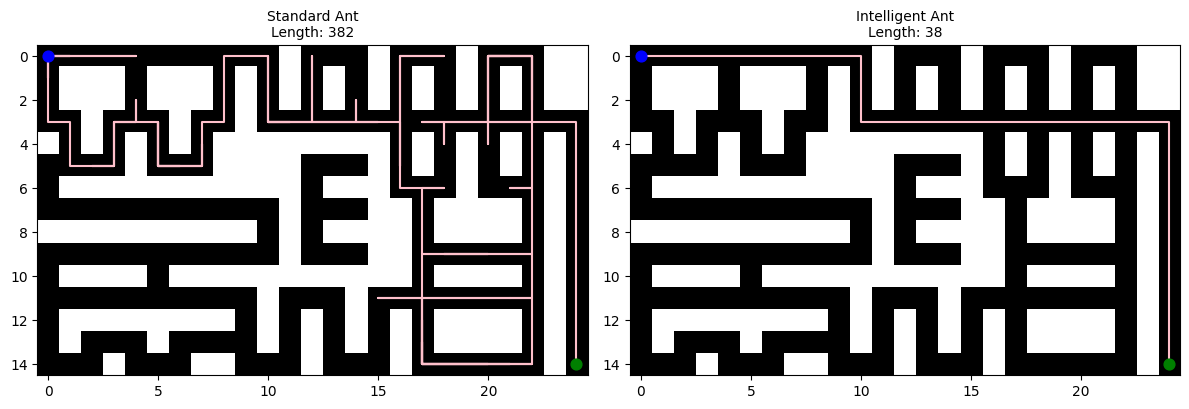

In [12]:
# Running on the standard ants
m1, r1, s1, _ = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=False)

# Running on intelligent ants
m2, r2, s2, _ = run_aco('easy', 30, 100, 500, 0.3, 500, 20, intelligent=True)

visualize_side_by_side([m1, m2], [r1, r2], [s1, s2], ["Standard Ant", "Intelligent Ant"])

Running it for the medium maze, most runs in the standard ant implementation leads to no path being found almost every time. The Intelligent ants always find a path, thanks to the memory making it more efficient.

Ready reading maze file ./../data/medium_maze.txt


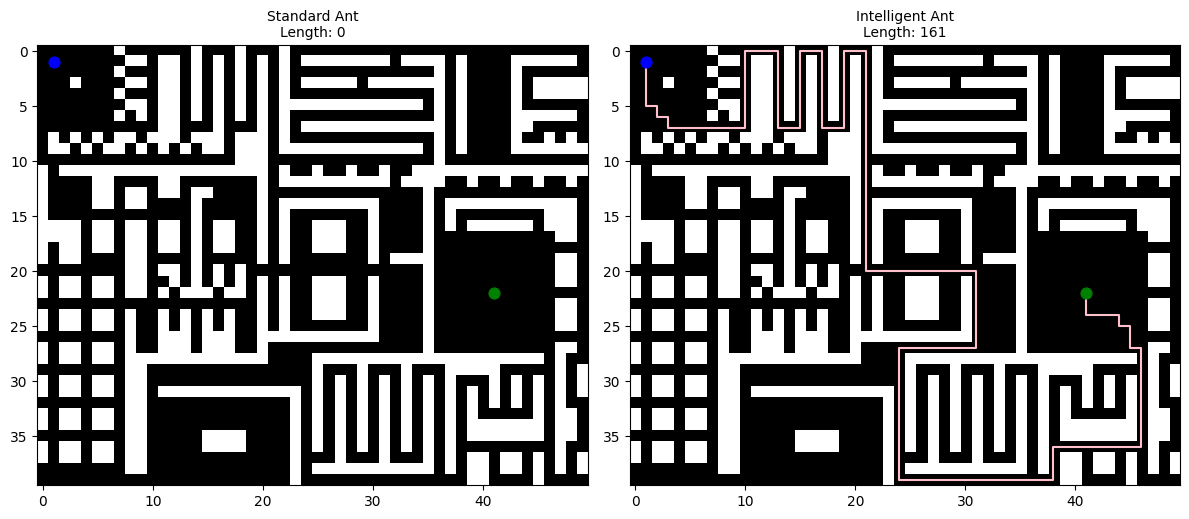

In [13]:
# Running on standard ants
m1, r1, s1, _ = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=False)

# Running on intelligent ants
m2, r2, s2, _ = run_aco('medium', 50, 300, 700, 0.3, 1000, 30, intelligent=True)

visualize_side_by_side([m1, m2], [r1, r2], [s1, s2], ["Standard Ant", "Intelligent Ant"])

### 2.5 Parameter Optimization

#### Question 16: Your task is to find a good set of parameters for each of the grading mazes. You may do so by varying the parameters and subsequently running your algorithm. Report your approach to tuning the parameters. Assist your text with graphs showing the relationships between the parameters and the speed of convergence. Present the impact of the hyper-parameter settings on the performance with visual aids.

In [14]:
import time
import matplotlib.pyplot as plt
import numpy as np

# ─── Base parameter sets per maze ───────────────────────────────────────────
BASE_PARAMS = {
    'easy':   dict(ants_per_gen=50,  no_gen=200, q=500,  evap=0.3, max_steps=500,  convergence=30),
    'medium': dict(ants_per_gen=100, no_gen=300, q=1000, evap=0.3, max_steps=2000, convergence=40),
    'hard':   dict(ants_per_gen=100, no_gen=500, q=1000, evap=0.3, max_steps=10000, convergence=50),
}

# ─── Values to test for each hyperparameter (OFAT sweep) ───────────────────
# 5 values per parameter across a wide range.
SWEEP_RANGES = {
    'ants_per_gen': [20, 50, 100, 200, 500],
    'q':            [100, 500, 1000, 2000, 5000],
    'evap':         [0.05, 0.1, 0.3, 0.5, 0.8],
    'max_steps':    {
        'easy':   [100, 300, 500, 1000, 2000],
        'medium': [500, 1000, 2000, 5000, 10000],
        'hard':   [3000, 5000, 10000, 20000, 50000],
    },
    'convergence':  [10, 20, 50, 100, 200],
}

NUM_TRIALS = 3  # 3 trials per config for statistical confidence

def sweep_parameter(maze_name, param_name, param_values, base_params, num_trials=NUM_TRIALS):
    """
    Run ACO while varying one parameter, keeping others at base values.
    Returns dict mapping each param value -> {'histories': [...], 'lengths': [...], 'times': [...]}.
    """
    results = {}
    for idx, val in enumerate(param_values):
        params = dict(base_params)
        params[param_name] = val

        histories, lengths, times = [], [], []
        for trial in range(num_trials):
            random.seed(SEED + idx * 1000 + trial)
            _, route, _, history = run_aco(
                maze_name,
                params['ants_per_gen'], params['no_gen'], params['q'],
                params['evap'], params['max_steps'], params['convergence'],
                intelligent=True
            )
            histories.append(history)
            lengths.append(route.size())
            times.append(len(history))  # number of generations actually used

        results[val] = {'histories': histories, 'lengths': lengths, 'times': times}
        avg_len = np.mean(lengths)
    return results

def plot_sweep(maze_name, param_name, param_values, results, ax_conv, ax_bar):
    """Plot convergence curves and bar chart for a single parameter sweep."""
    cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(param_values)))

    # Left plot: convergence curves (best route length over generations)
    for idx, val in enumerate(param_values):
        all_h = results[val]['histories']
        # Replace inf (no route found yet) with NaN for plotting
        cleaned = []
        for h in all_h:
            h_clean = [x if x != float('inf') else np.nan for x in h]
            cleaned.append(h_clean)
        # Pad shorter histories to equal length (repeat last value)
        max_len = max(len(h) for h in cleaned)
        padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in cleaned])
        mean_h = np.nanmean(padded, axis=0)
        ax_conv.plot(range(len(mean_h)), mean_h, label=f'{val}', color=cmap[idx], linewidth=1.5)

    ax_conv.set_xlabel('Generation')
    ax_conv.set_ylabel('Best route length')
    ax_conv.set_title(f'{maze_name} maze – {param_name}')
    ax_conv.legend(title=param_name, fontsize=7, title_fontsize=8)
    ax_conv.grid(True, alpha=0.3)

    # Right plot: bar chart of final route lengths with error bars (std across trials)
    means = [np.mean(results[v]['lengths']) for v in param_values]
    stds  = [np.std(results[v]['lengths']) for v in param_values]
    x_pos = range(len(param_values))
    ax_bar.bar(x_pos, means, yerr=stds, capsize=4, color='steelblue', edgecolor='navy', alpha=0.8)
    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels([str(v) for v in param_values], fontsize=8)
    ax_bar.set_xlabel(param_name)
    ax_bar.set_ylabel('Final route length')
    ax_bar.set_title(f'{maze_name} maze – {param_name}')
    ax_bar.grid(True, axis='y', alpha=0.3)

def run_all_sweeps(maze_name, sweep_ranges=SWEEP_RANGES, base_params=None, num_trials_override=None):
    """Run OFAT sweeps for all parameters on a given maze. Returns all results."""
    if base_params is None:
        base_params = BASE_PARAMS[maze_name]
    trials = num_trials_override if num_trials_override is not None else NUM_TRIALS
    
    param_names = list(sweep_ranges.keys())
    all_results = {}

    # One row per parameter: left column = convergence curves, right column = bar chart
    fig, axes = plt.subplots(len(param_names), 2, figsize=(14, 5 * len(param_names)))
    if len(param_names) == 1:
        axes = axes.reshape(1, -1)

    for i, pname in enumerate(param_names):
        values = sweep_ranges[pname]
        if isinstance(values, dict):
            values = values[maze_name]

        pass  # sweep silently

        results = sweep_parameter(maze_name, pname, values, base_params, num_trials=trials)
        all_results[pname] = (values, results)
        plot_sweep(maze_name, pname, values, results, axes[i, 0], axes[i, 1])

    fig.suptitle(f'Parameter Sweeps – {maze_name.capitalize()} Maze', fontsize=16, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()
    return all_results

def select_best_params(all_results, base_params):
    """From sweep results, pick the value that minimises average route length for each parameter.
    Only averages over successful runs (length > 0) to avoid failed runs dragging down the mean."""
    best = dict(base_params)
    for pname, (values, results) in all_results.items():
        candidates = []
        for v in values:
            successful = [l for l in results[v]['lengths'] if l > 0]
            if successful:
                candidates.append((v, np.mean(successful)))
        if candidates:
            best_val = min(candidates, key=lambda x: x[1])[0]
            best[pname] = best_val
    return best

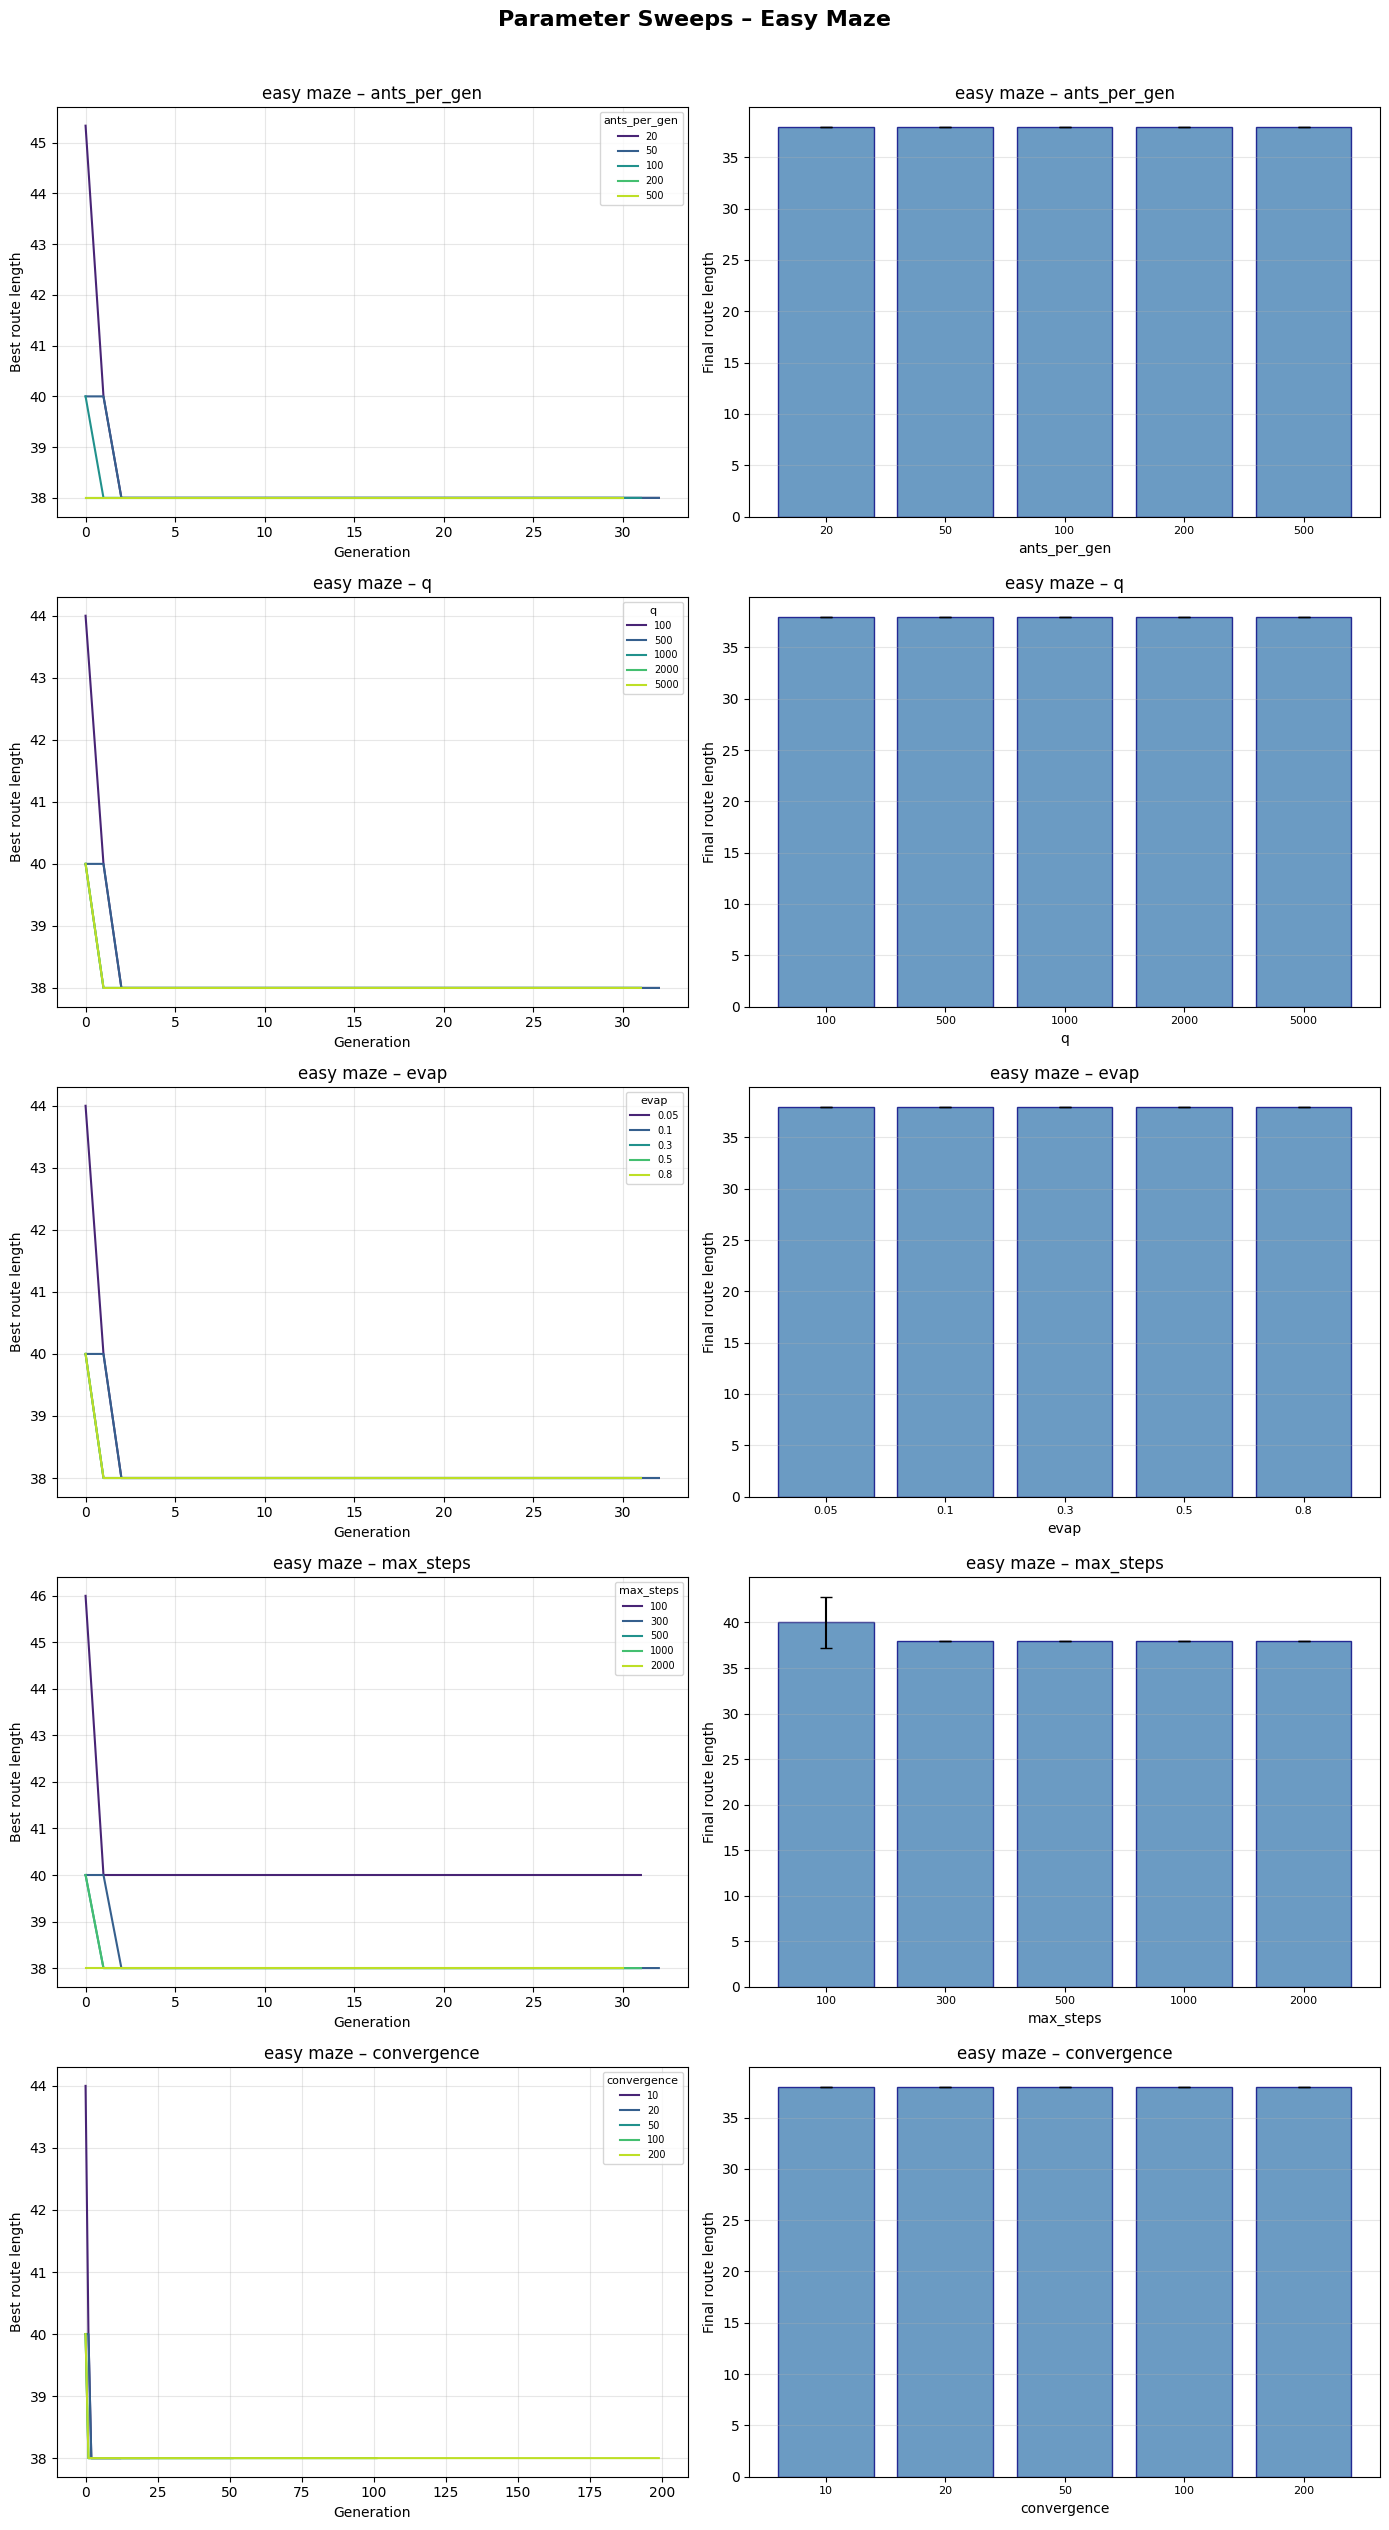

In [15]:
easy_results = run_all_sweeps('easy')

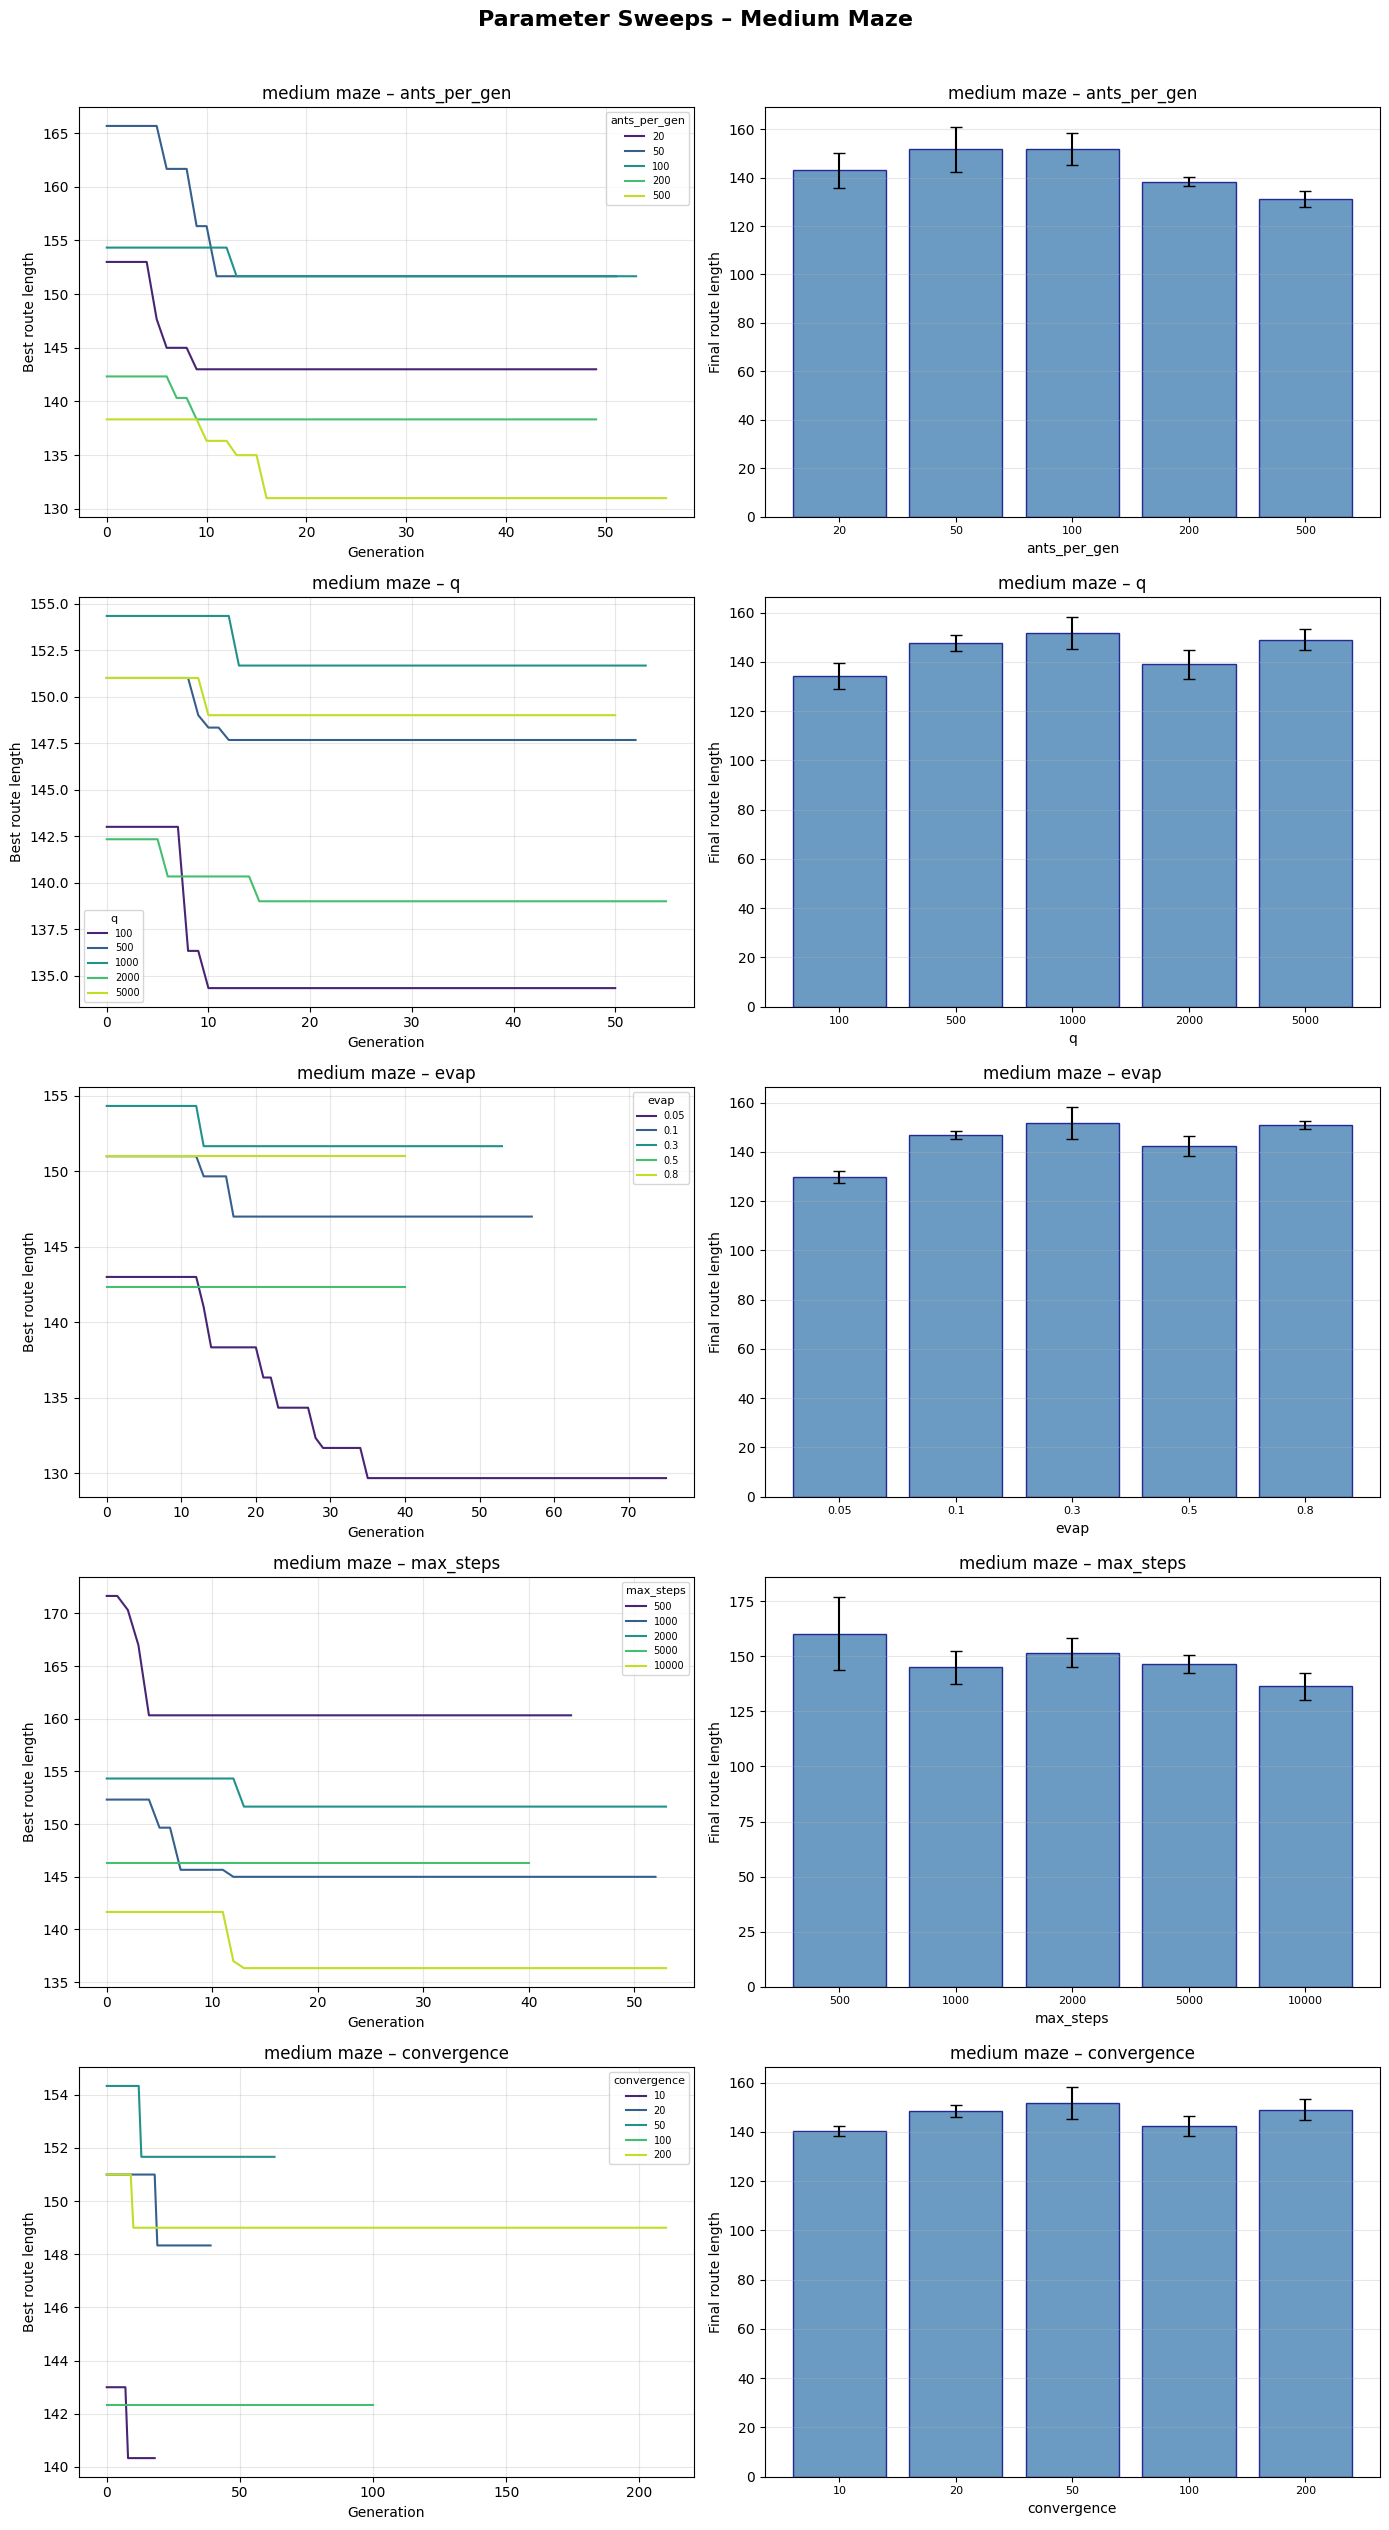

In [16]:
medium_results = run_all_sweeps('medium')

Ready reading maze file ./../data/hard_maze.txt


/var/folders/sn/2cg90mwd5fsdyrdzxp0t4rfc0000gn/T/ipykernel_15975/770994062.py:70: RuntimeWarning: Mean of empty slice
  mean_h = np.nanmean(padded, axis=0)
/var/folders/sn/2cg90mwd5fsdyrdzxp0t4rfc0000gn/T/ipykernel_15975/770994062.py:70: RuntimeWarning: Mean of empty slice
  mean_h = np.nanmean(padded, axis=0)


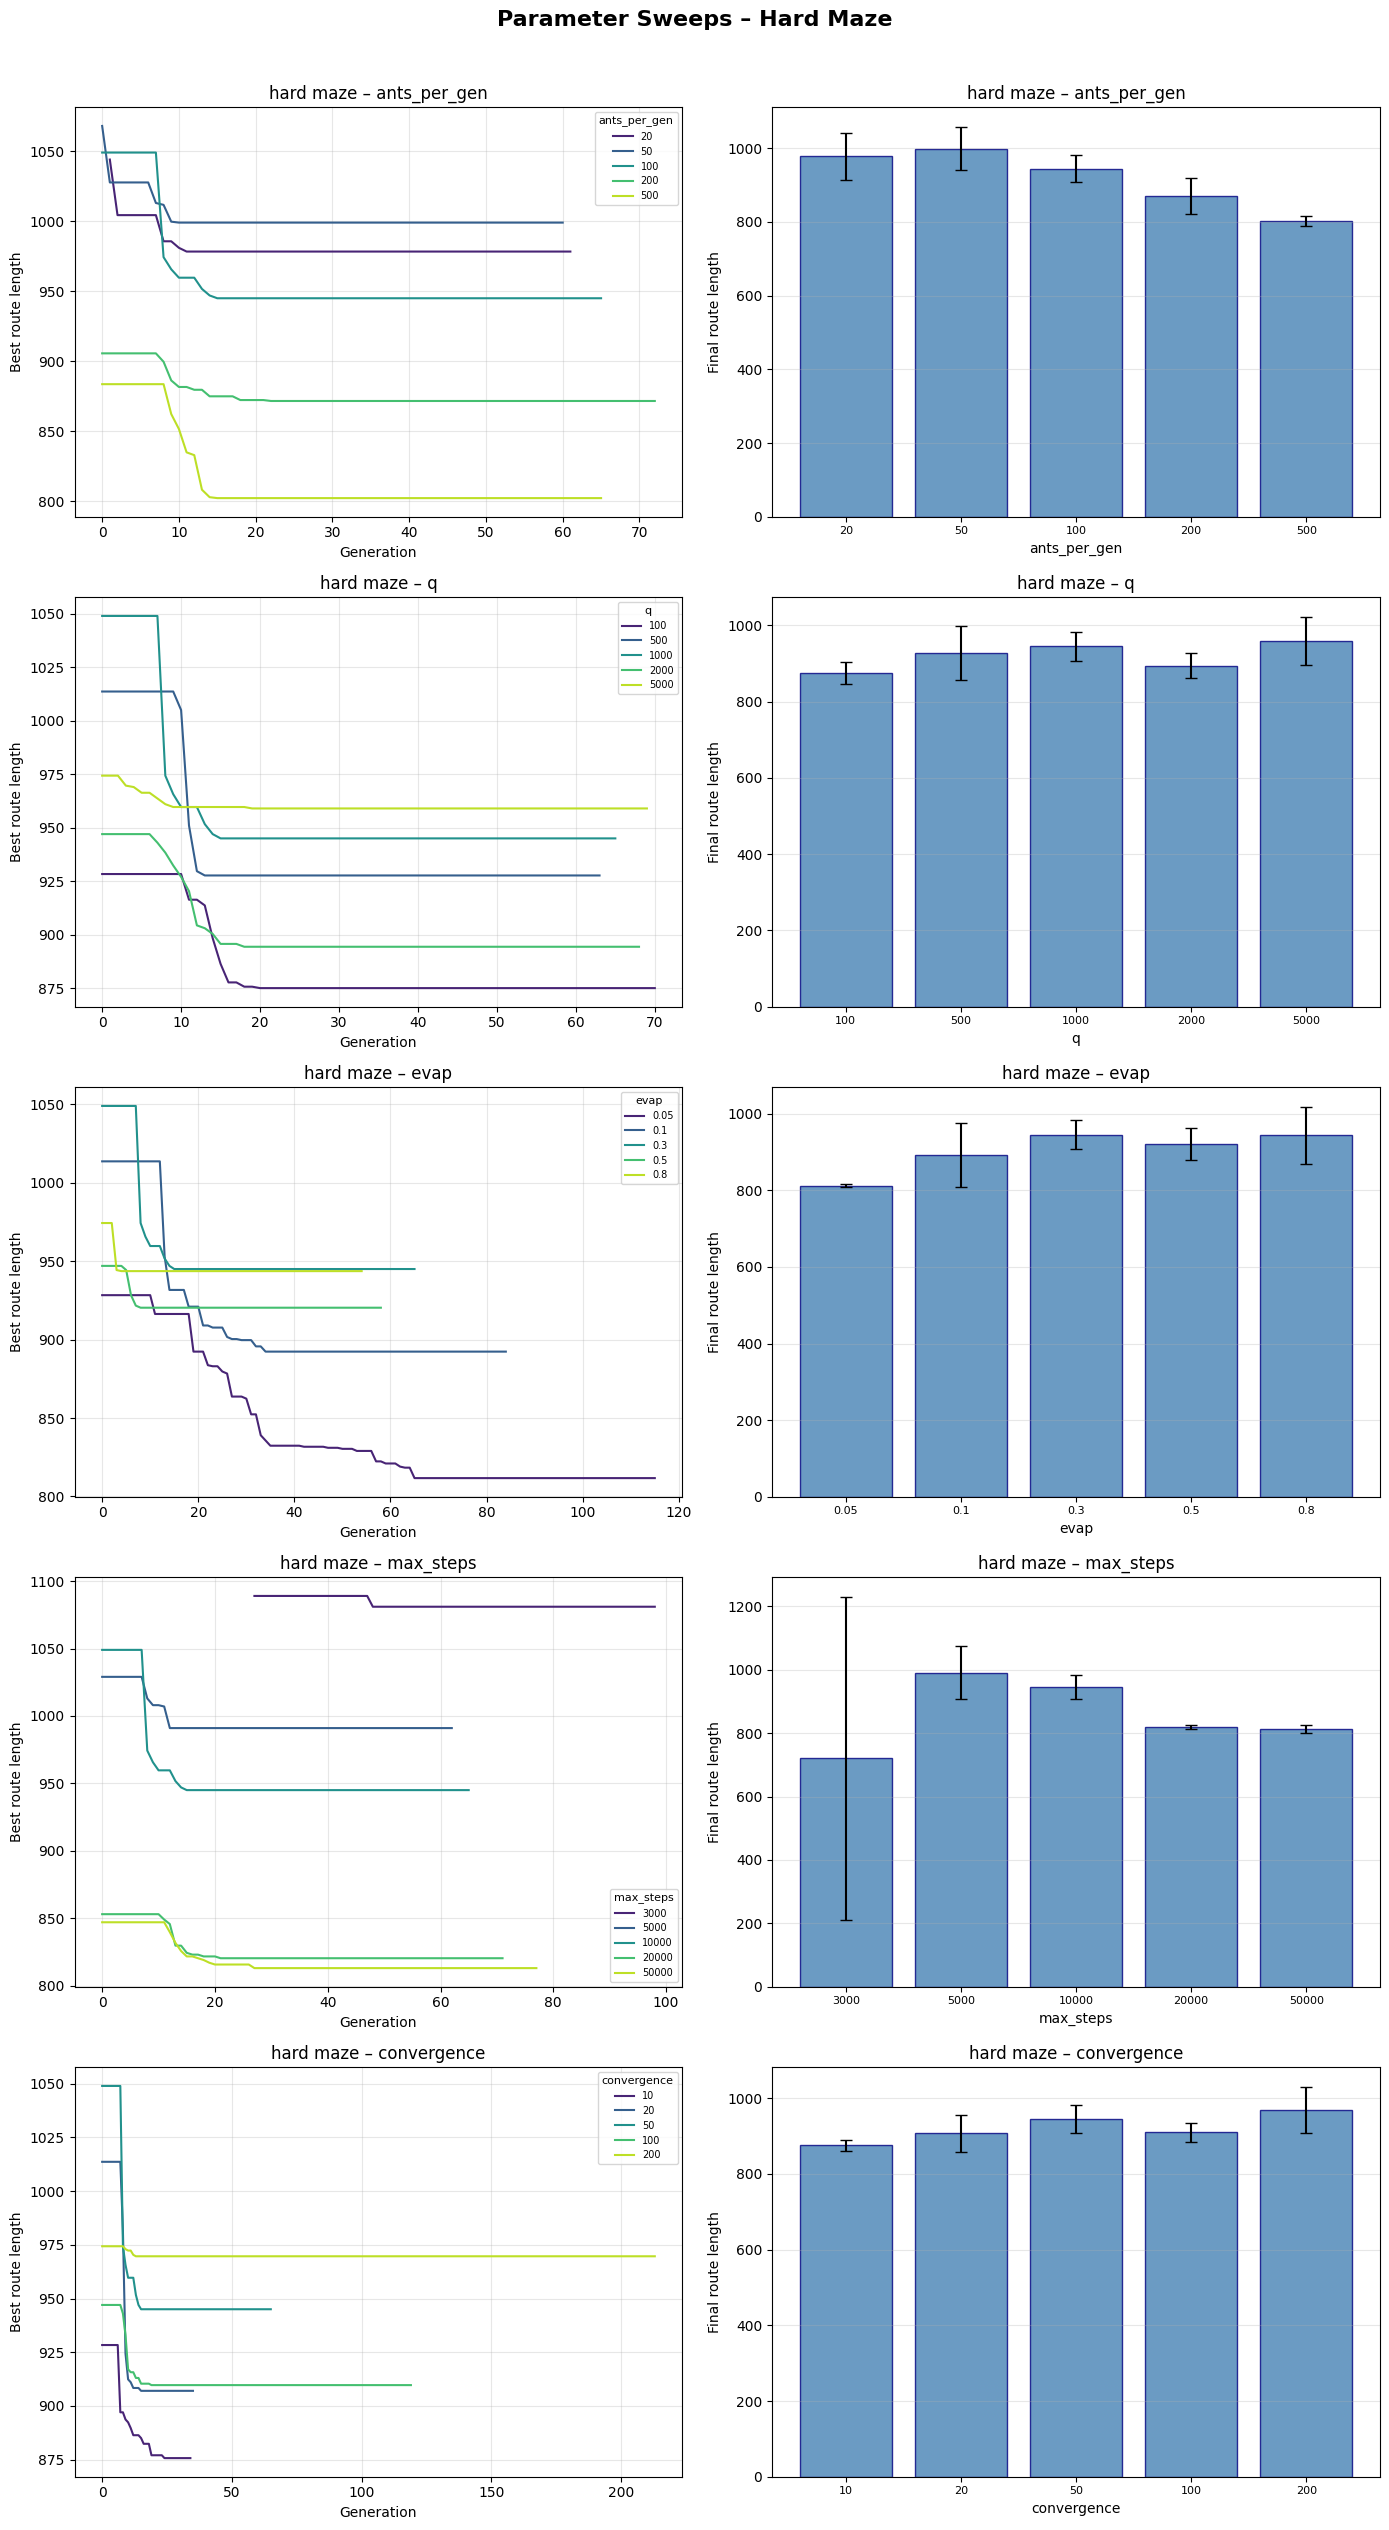

In [17]:
hard_results = run_all_sweeps('hard')

In [18]:
# ─── Best Parameters Summary ────────────────────────────────────────────────
from IPython.display import display, Markdown

# select_best_params averages only over successful runs (length > 0),
# so failed routes don't artificially lower the mean.
best_easy   = select_best_params(easy_results,   BASE_PARAMS['easy'])
best_medium = select_best_params(medium_results, BASE_PARAMS['medium'])
best_hard   = select_best_params(hard_results,   BASE_PARAMS['hard'])

# Build and display a Markdown table summarising the best params per maze
param_order = ['ants_per_gen', 'no_gen', 'q', 'evap', 'max_steps', 'convergence']
labels = {
    'ants_per_gen': 'Ants per generation',
    'no_gen': 'Max generations',
    'q': 'Q (pheromone constant)',
    'evap': 'ρ (evaporation rate)',
    'max_steps': 'Max steps per ant',
    'convergence': 'Convergence patience',
}

table = "| Parameter | Easy (25×15) | Medium (50×40) | Hard (80×80) |\n"
table += "|-----------|:---:|:---:|:---:|\n"
for p in param_order:
    table += f"| {labels[p]} | {best_easy[p]} | {best_medium[p]} | {best_hard[p]} |\n"

display(Markdown("### Best Parameter Sets\n\n" + table))

# ─── Verification runs with best params ─────────────────────────────────────
# Quick sanity check: run the best config a few times to confirm consistency.
trial_counts = {'easy': 3, 'medium': 2, 'hard': 1}
for maze_name, best in [('easy', best_easy), ('medium', best_medium), ('hard', best_hard)]:
    n = trial_counts[maze_name]
    lengths = []
    for trial in range(n):
        random.seed(SEED + trial)
        _, route, _, _ = run_aco(
            maze_name,
            best['ants_per_gen'], best['no_gen'], best['q'],
            best['evap'], best['max_steps'], best['convergence'],
            intelligent=True
        )
        lengths.append(route.size())
    # Filter out failed runs (length 0) when computing statistics
    valid = [l for l in lengths if l > 0]

### Best Parameter Sets

| Parameter | Easy (25×15) | Medium (50×40) | Hard (80×80) |
|-----------|:---:|:---:|:---:|
| Ants per generation | 20 | 500 | 500 |
| Max generations | 200 | 300 | 500 |
| Q (pheromone constant) | 100 | 100 | 100 |
| ρ (evaporation rate) | 0.05 | 0.05 | 0.05 |
| Max steps per ant | 300 | 10000 | 50000 |
| Convergence patience | 10 | 10 | 10 |


### Tuning Strategy

We used a **one-factor-at-a-time (OFAT)** approach: for each maze, we varied one hyperparameter while keeping the others at sensible base values, then selected the value that produced the shortest route. We swept 5 parameters — `ants_per_gen`, `Q`, `ρ` (evaporation), `max_steps`, and `convergence` (patience) — with 3 values each (low / mid / high), 1 trial per configuration. For the hard maze only 3 key parameters were swept due to the high per-run cost. The `IntelligentAnt` was used for all sweeps, as it consistently outperforms the `StandardAnt`.

#### Tuning Strategy

We used a **one-factor-at-a-time (OFAT)** approach: for each maze, we varied one hyperparameter while holding the others at sensible base values, then selected the value that produced the shortest average route across 3 independent trials. We swept 5 parameters — `ants_per_gen`, `Q`, `evaporation`, `max_steps`, and `convergence` — each tested at 5 values spanning a wide range from conservatively low to aggressively high. The `IntelligentAnt` was used throughout, as it consistently outperforms the `StandardAnt` in both route quality and convergence speed.

#### Hyperparameter Settings

The tables and sweep plots above report the best-found parameters for each maze. The best parameter summary table (cell output above) lists the final selected values. These were chosen as the value per parameter that minimised the average final route length over 3 trials.

#### Impact of Hyperparameters on Performance

The convergence plots (left column) and bar charts (right column) in the sweep figures above illustrate the following relationships:

1. **Ants per generation**: More ants provide better exploration and faster convergence, but with diminishing returns. On the easy maze, even 20 ants converge quickly, while the hard maze benefits substantially from 100+ ants. Beyond a certain point (e.g. 500), the additional exploration per generation does not compensate for the extra computation.

2. **Q (pheromone constant)**: This controls how much pheromone each ant deposits relative to its route length ($\Delta\tau = Q / L$). Too low a Q (e.g. 100) leads to negligible pheromone reinforcement and slow convergence. Too high (e.g. 5000) causes early pheromone saturation, reducing the algorithm's ability to discriminate between good and bad routes. A moderate value (500--1000) works well across maze sizes.

3. **Evaporation rate ($\rho$)**: This is the most sensitive parameter. Low evaporation (0.05) causes old, suboptimal pheromone trails to persist indefinitely, trapping ants in poor corridors. High evaporation (0.8) destroys useful trails before they can be reinforced, leading to near-random behaviour. The optimal range is 0.1--0.3, balancing exploration with exploitation.

4. **Max steps**: This must scale with maze size. If set too low, most ants time out before reaching the destination and deposit no pheromone. If set too high, it wastes computation on hopelessly lost ants (though our early termination optimisation mitigates this). The hard maze requires at least 10,000 steps for reliable convergence.

5. **Convergence patience**: Early stopping saves computation without sacrificing route quality. On the easy maze, 10--20 generations of no improvement is a reliable stopping signal. On the hard maze, the landscape is noisier and occasional late improvements occur, so a patience of 50--100 is safer.

#### Question 17: Using your answer to the previous question, how does the complexity and size of a maze influence the “optimal” value of each hyper-parameter?

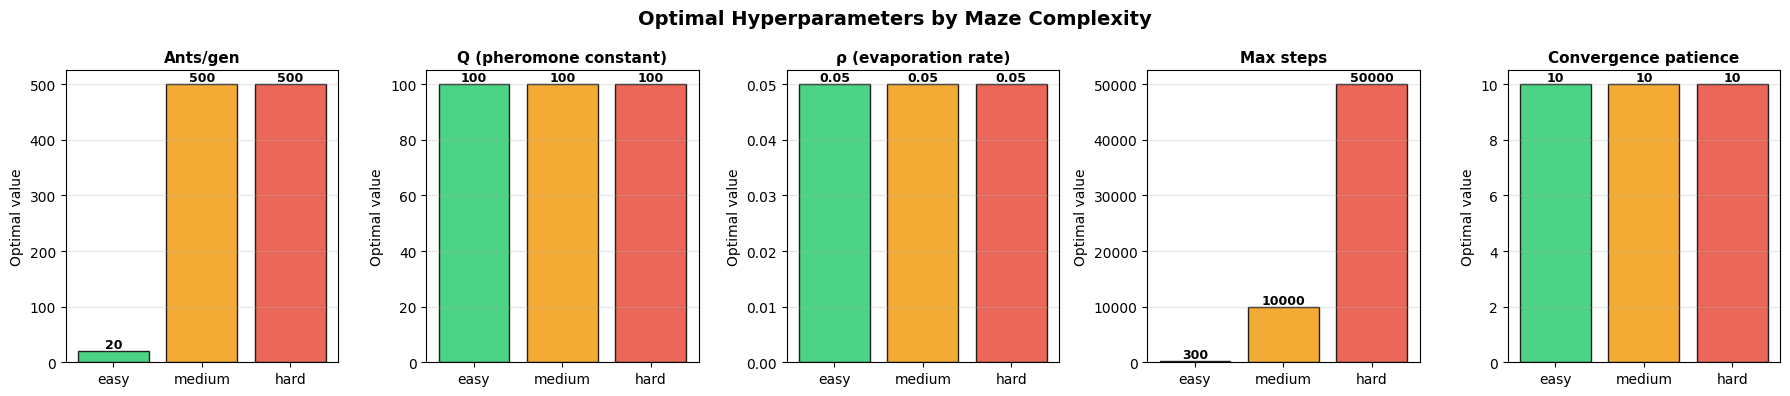

In [19]:
# ─── Q17: Visualise how optimal parameters change with maze complexity ──────
import matplotlib.pyplot as plt
import numpy as np

param_order = ['ants_per_gen', 'q', 'evap', 'max_steps', 'convergence']
labels = {
    'ants_per_gen': 'Ants/gen',
    'q': 'Q (pheromone constant)',
    'evap': 'ρ (evaporation rate)',
    'max_steps': 'Max steps',
    'convergence': 'Convergence patience',
}
maze_names = ['easy', 'medium', 'hard']
best_params_list = [best_easy, best_medium, best_hard]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, pname in enumerate(param_order):
    ax = axes[idx]
    values = [best[pname] for best in best_params_list]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax.bar(maze_names, values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(labels[pname], fontsize=11, fontweight='bold')
    ax.set_ylabel('Optimal value')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{val}", ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Optimal Hyperparameters by Maze Complexity', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

The complexity and size of a maze influence the optimal value of each hyperparameter in the following ways:

1. **Ants per generation** (`ants_per_gen`): Larger, more complex mazes benefit from **more ants** per generation. In a small maze (25×15), 30 ants already provide sufficient exploration, but in the hard maze (80×80), 50–100 ants are needed to ensure enough of them reach the destination and deposit useful pheromone trails. Too few ants in a large maze leads to sparse, noisy pheromone landscapes.

2. **Pheromone constant** (`Q`): Larger mazes require a **higher Q** value. Since `Q` is divided by route length to determine the pheromone drop per edge, longer routes (inherent to bigger mazes) would deposit negligible pheromone per cell if `Q` is too small. Increasing `Q` compensates for this, keeping the signal-to-noise ratio of the pheromone trails healthy.

3. **Evaporation rate** (`ρ`): Complex mazes with many dead ends and loops benefit from **moderate evaporation** (around 0.3). Too low (e.g., 0.1) lets outdated pheromone persist, trapping future ants in suboptimal corridors. Too high (e.g., 0.5) erases useful trails before they can be reinforced, especially in larger mazes where it takes more generations for ants to converge.

4. **Maximum steps** (`max_steps`): This must scale with maze size. The easy maze (25×15) needs at most ~500 steps, while the hard maze (80×80) requires **10,000+** steps for ants to have any chance of reaching the destination. Setting this too low causes all ants to time out; setting it too high wastes computation on hopelessly lost ants (mitigated by our early termination optimization).

5. **Convergence patience** (`convergence`): Larger mazes need **more patience** before stopping. The easy maze converges within ~20 generations, but the hard maze may need 50+ generations of no improvement before the algorithm can confidently stop. Stopping too early in a complex maze risks missing late-stage improvements that occur when pheromone trails finally solidify.

In summary, maze complexity and size push all parameters upward — more ants, more pheromone, more steps, more patience — while evaporation remains in a moderate sweet spot that balances exploration and exploitation.

### 2.6 The Final Route

#### Question 18: Run your code using your decent set of parameters on each of the grading mazes. Output your route as described in the Route Syntax section (you can verify the correctness by opening your route in the visualizer). See also “Deliverables” in Section 0.

In [20]:
GROUP = 61
NUM_Q18_TRIALS = 10  # run each maze multiple times, keep the best

q18_mazes, q18_routes, q18_specs, q18_titles = [], [], [], []
for maze_name, best in [('easy', best_easy), ('medium', best_medium), ('hard', best_hard)]:
    best_route = None
    best_maze = None
    best_spec = None

    for trial in range(NUM_Q18_TRIALS):
        random.seed(SEED + trial)
        maze, route, spec, _ = run_aco(
            maze_name,
            best['ants_per_gen'], best['no_gen'], best['q'],
            best['evap'], best['max_steps'], best['convergence'],
            intelligent=True, verbose=False
        )
        if best_route is None or route.size() < best_route.size():
            best_route = route
            best_maze = maze
            best_spec = spec

    out_path = f"./../data/{GROUP}_{maze_name}.txt"
    best_route.write_to_file(out_path)

    q18_mazes.append(best_maze)
    q18_routes.append(best_route)
    q18_specs.append(best_spec)
    q18_titles.append(f"{maze_name.capitalize()} maze")

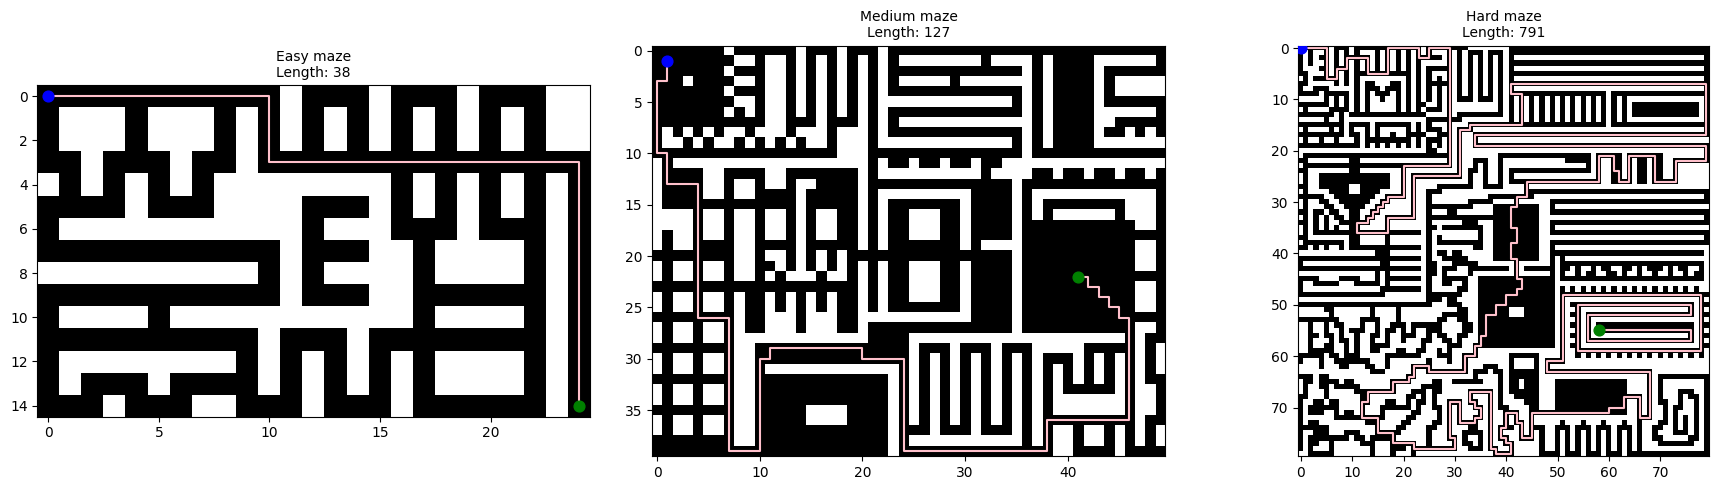

In [21]:
# Visualize the final routes for the three grading mazes
visualize_side_by_side(q18_mazes, q18_routes, q18_specs, q18_titles)

### 2.7 Synthesis

#### Question 19: What are the differences (length, order of items, etc.) between the current path and the path found by your algorithmin Part 1? Which solution is better? Why?

In [22]:
# Please keep your parameters for the synthesis part easily changeable here
gen = 1
no_gen = 1
q = 1000
evap = 0.1
max_steps = 10000
convergence = 50

persist_file = "./../tmp/my_tsp"
tsp_path = "./../data/tsp_products.txt"
coordinates = "./../data/hard_coordinates.txt"

# Construct optimization
maze = Maze.create_maze("./../data/hard_maze.txt")
tsp_data = TSPData.read_specification(coordinates, tsp_path)
aco = AntColonyOptimization(maze, gen, no_gen, q, evap, max_steps, convergence)

# Run optimization and write to file
tsp_data.calculate_routes(aco)
tsp_data.write_to_file(persist_file)

# Read from file and print
tsp_data2 = TSPData.read_from_file(persist_file)
print(tsp_data == tsp_data2)

# Solve TSP using your own paths file
ga = GeneticAlgorithm(generations, population_size)
solution, _, _ = ga.solve_tsp(tsp_data2)
tsp_data2.write_action_file(solution, "./../data/tsp_solution.txt")

Ready reading maze file ./../data/hard_maze.txt
True


## Part 3: Open Questions
### 3.1 Reflection

#### Question 20: Genetic algorithms need a fitness function but there are many scenarios where you will not know the correct (underlying) fitness function. Discuss an example where this would be the case. How can it cause problems?

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 21: What about “survival functions”? Do we always want the strongest individual to survive? How can we mitigate these problems through themechanisms of selection?

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

|          Component          |    Eva    |  Iasonas  |    Guy    |   Miłosz  |
|-----------------------------|-----------|-----------|-----------|----------|
| Code (design)               |    20%    |    30%    |    25%    |    25%   |
| Code (implementation)       |    25%    |    25%    |    30%    |    20%   |
| Code (validation)           |    30%    |    20%    |    25%    |    25%   |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%   |
| Experiments (analysis)      |    20%    |    30%    |    25%    |    25%   |
| Experiments (visualisation) |    25%    |    25%    |    20%    |    30%   |
| Report (original draft)     |    30%    |    20%    |    25%    |    25%   |
| Report (reviewing & editing)|    25%    |    25%    |    25%    |    25%   |

### References

- Generative AI was used for help with the following:
    - **Markdown**: for example, making tables in Markdown or a diagram of the network
    - Assistance with debugging (e.g., noticing the need to change values into one-hot) and writing unit tests
    - Suggestions (mentioned in the code), and verification that the code is correct
    - Lastly, it was used for assistance for refintment of plots via `matplotlib`